# 08C — Disease-Only Final Baseline — 3-Seed Replication Summary

**Project:** Pedi-CGAM Lite  
**Frozen backbone:** ResNet50 @ 320×320  
**Frozen loss:** Binary Focal Loss (`gamma = 2.0`, no alpha weighting)  
**Seeds:** 42, 123, 2026  
**Purpose:** quantify validation stability of the final disease-only baseline before adding finding supervision.

This notebook performs **no model training**.

## Required Kaggle inputs

Attach the saved outputs of:

- `06C_ResNet50_320_FocalLoss_FIXED` — seed 42
- `08A_DiseaseOnly_Focal_Seed123` — seed 123
- `08B_DiseaseOnly_Focal_Seed2026` — seed 2026

You may attach the generated ZIPs instead of saved notebook outputs.

You do **not** need VinDr-PCXR, Stage 02, GPU, or Internet.

## Important interpretation rule

Seed 42 was also the validation seed used during the earlier loss-selection stage. Therefore this 3-seed table is best described as a **replication/stability summary of the selected configuration**, not as an independent unbiased estimate of generalization.

For later paper-quality comparisons (disease-only vs multitask vs box-guided vs CGAM), the same three seeds should be used consistently.

## Outputs

The notebook reports:

- seed-wise metrics
- mean ± **sample standard deviation** (`ddof=1`)
- Head / Middle / Tail stability
- per-class AUPRC mean ± SD
- rare-class instability diagnostics
- reproducibility/fairness checks
- one complete ZIP

Expected final ZIP:

`/kaggle/working/PediCGAM_Stage08C_DiseaseOnly_3Seed_Summary_All_Outputs.zip`


In [1]:
# ============================================================
# 1. Imports / constants
# ============================================================
from pathlib import Path
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KAGGLE_INPUT = Path("/kaggle/input")

OUTPUT_DIR = Path(
    "/kaggle/working/PediCGAM/stage08c_diseaseonly_3seed_summary"
)
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPECTED = {
    "L02_ResNet50_320_FocalLoss": 42,
    "D01_ResNet50_320_Focal_Seed123": 123,
    "D02_ResNet50_320_Focal_Seed2026": 2026,
}

EXPECTED_SPLIT_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

EXPECTED_COMMON = {
    "backbone": "ResNet50",
    "image_size": 320,
    "loss": "BinaryFocalLoss",
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "batch_size": 8,
    "max_epochs": 25,
    "early_stopping_patience": 5,
    "train_images": 5408,
    "validation_images": 1159,
    "calibration_used": False,
    "official_test_used": False,
}

print("Expected seed runs:")
for exp_id, seed in EXPECTED.items():
    print(f"- seed {seed}: {exp_id}")


Expected seed runs:
- seed 42: L02_ResNet50_320_FocalLoss
- seed 123: D01_ResNet50_320_Focal_Seed123
- seed 2026: D02_ResNet50_320_Focal_Seed2026


In [2]:
# ============================================================
# 2. Extract attached ZIPs if present
# ============================================================
EXTRACT_ROOT = Path("/kaggle/working/stage08c_extracted_inputs")
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

for zp in KAGGLE_INPUT.rglob("*.zip"):
    name = zp.name.lower()

    if not any(
        token in name
        for token in [
            "focalloss",
            "seed123",
            "seed2026",
            "l02",
            "d01",
            "d02",
        ]
    ):
        continue

    target = EXTRACT_ROOT / zp.stem

    if target.exists():
        continue

    target.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(target)
        print("✅ Extracted:", zp)
    except zipfile.BadZipFile:
        print("⚠️ Invalid ZIP skipped:", zp)


✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/08a-diseaseonly-focal-seed123/D01_ResNet50_320_Focal_Seed123_All_Outputs.zip
✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/06c-resnet50-320-focalloss-fixed/L02_ResNet50_320_FocalLoss_All_Outputs.zip
✅ Extracted: /kaggle/input/notebooks/kalloldaskushol/08b-diseaseonly-focal-seed2026/D02_ResNet50_320_Focal_Seed2026_All_Outputs.zip


In [3]:
# ============================================================
# 3. Discover all three runs by config.json
# ============================================================
SEARCH_ROOTS = [KAGGLE_INPUT, EXTRACT_ROOT]

discovered = {}

for root in SEARCH_ROOTS:
    for config_path in root.rglob("config.json"):
        try:
            cfg = json.loads(config_path.read_text())
        except Exception:
            continue

        exp_id = cfg.get("experiment_id")

        if exp_id not in EXPECTED:
            continue

        candidate_root = config_path.parent

        completeness = sum(
            (candidate_root / p).exists()
            for p in [
                "tables/summary_metrics.csv",
                "tables/head_middle_tail_metrics.csv",
                "tables/per_class_metrics.csv",
                "tables/validation_predictions.csv",
                "training_history.csv",
                "environment_info.json",
                "final_integrity_status.csv",
                "best_model.pth",
            ]
        )

        current = discovered.get(exp_id)

        if current is None or completeness > current["completeness"]:
            discovered[exp_id] = {
                "root": candidate_root,
                "config": cfg,
                "config_path": config_path,
                "completeness": completeness,
            }

print("Discovery:")
for exp_id, seed in EXPECTED.items():
    if exp_id in discovered:
        print(
            f"✅ seed {seed}:",
            discovered[exp_id]["root"],
            "| completeness:",
            discovered[exp_id]["completeness"],
        )
    else:
        print(f"❌ seed {seed}: missing")

missing = [x for x in EXPECTED if x not in discovered]

if missing:
    raise FileNotFoundError(
        "Missing seed outputs: "
        + ", ".join(missing)
        + ". Attach seed 42, 123, and 2026 saved outputs/ZIPs."
    )

print("\n✅ All three seed runs discovered.")


Discovery:
✅ seed 42: /kaggle/input/notebooks/kalloldaskushol/06c-resnet50-320-focalloss-fixed/PediCGAM/L02_ResNet50_320_FocalLoss | completeness: 8
✅ seed 123: /kaggle/input/notebooks/kalloldaskushol/08a-diseaseonly-focal-seed123/PediCGAM/D01_ResNet50_320_Focal_Seed123 | completeness: 8
✅ seed 2026: /kaggle/input/notebooks/kalloldaskushol/08b-diseaseonly-focal-seed2026/PediCGAM/D02_ResNet50_320_Focal_Seed2026 | completeness: 8

✅ All three seed runs discovered.


In [4]:
# ============================================================
# 4. Common-protocol / integrity verification
# ============================================================
verification_rows = []

for exp_id, seed in EXPECTED.items():
    info = discovered[exp_id]
    cfg = info["config"]
    root = info["root"]

    row = {
        "experiment_id": exp_id,
        "expected_seed": seed,
        "seed_ok": int(cfg.get("seed", -1)) == seed,
        "split_sha256_ok":
            cfg.get("split_manifest_sha256") == EXPECTED_SPLIT_SHA256,
    }

    for key, expected in EXPECTED_COMMON.items():
        actual = cfg.get(key)

        if isinstance(expected, float):
            passed = (
                actual is not None
                and np.isclose(float(actual), expected)
            )
        else:
            passed = actual == expected

        row[f"{key}_ok"] = bool(passed)

    focal_cfg = cfg.get("focal_loss", {})

    row["focal_gamma_2_ok"] = np.isclose(
        float(focal_cfg.get("gamma", np.nan)),
        2.0,
    )
    row["focal_alpha_none_ok"] = (
        focal_cfg.get("alpha_weighting", "NOT_NONE") is None
    )

    integrity_path = root / "final_integrity_status.csv"

    if not integrity_path.exists():
        row["run_integrity_pass"] = False
    else:
        integrity_df = pd.read_csv(integrity_path)
        row["run_integrity_pass"] = bool(
            integrity_df["passed"].all()
        )

    row["all_checks_pass"] = all(
        value
        for key, value in row.items()
        if key.endswith("_ok")
        or key == "run_integrity_pass"
    )

    verification_rows.append(row)

verification_df = pd.DataFrame(verification_rows)

display(verification_df)

verification_df.to_csv(
    TABLE_DIR / "three_seed_protocol_verification.csv",
    index=False,
)

if not verification_df["all_checks_pass"].all():
    raise RuntimeError(
        "At least one seed run failed the frozen-protocol/integrity gate."
    )

print("✅ All three runs pass the frozen-protocol gate.")


,experiment_id,expected_seed,seed_ok,split_sha256_ok,backbone_ok,image_size_ok,loss_ok,optimizer_ok,learning_rate_ok,weight_decay_ok,...,max_epochs_ok,early_stopping_patience_ok,train_images_ok,validation_images_ok,calibration_used_ok,official_test_used_ok,focal_gamma_2_ok,focal_alpha_none_ok,run_integrity_pass,all_checks_pass
0,L02_ResNet50_320_FocalLoss,42,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,D01_ResNet50_320_Focal_Seed123,123,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,D02_ResNet50_320_Focal_Seed2026,2026,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


✅ All three runs pass the frozen-protocol gate.


In [5]:
# ============================================================
# 5. Load seed-wise summary metrics
# ============================================================
def metric_dict(path):
    df = pd.read_csv(path)

    if not {"metric", "value"}.issubset(df.columns):
        raise ValueError(f"Unexpected summary format: {path}")

    return dict(
        zip(
            df["metric"].astype(str),
            df["value"].astype(float),
        )
    )

seed_rows = []
per_class_by_seed = {}

for exp_id, seed in EXPECTED.items():
    root = discovered[exp_id]["root"]

    summary = metric_dict(
        root / "tables" / "summary_metrics.csv"
    )

    hmt = pd.read_csv(
        root / "tables" / "head_middle_tail_metrics.csv"
    )
    hmt_map = dict(
        zip(
            hmt["group"],
            hmt["macro_AUPRC"],
        )
    )

    env = json.loads(
        (root / "environment_info.json").read_text()
    )

    pc = pd.read_csv(
        root / "tables" / "per_class_metrics.csv"
    )

    per_class_by_seed[seed] = pc.copy()

    seed_rows.append({
        "seed": seed,
        "experiment_id": exp_id,
        "macro_AUPRC_14":
            summary["pathology14_macro_AUPRC"],
        "head_macro_AUPRC":
            float(hmt_map["Head"]),
        "middle_macro_AUPRC":
            float(hmt_map["Middle"]),
        "tail_macro_AUPRC":
            float(hmt_map["Tail"]),
        "macro_AUROC_14":
            summary["pathology14_macro_AUROC"],
        "macro_F1_at_0.5":
            summary["pathology14_macro_F1_at_0.5"],
        "macro_sensitivity_at_0.5":
            summary["pathology14_macro_sensitivity_at_0.5"],
        "macro_specificity_at_0.5":
            summary["pathology14_macro_specificity_at_0.5"],
        "macro_balanced_accuracy_at_0.5":
            summary["pathology14_macro_balanced_accuracy_at_0.5"],
        "best_epoch":
            int(env["best_epoch"]),
        "training_minutes":
            float(env["training_minutes"]),
        "peak_gpu_memory_gb":
            float(env["peak_gpu_memory_gb"]),
    })

seed_df = (
    pd.DataFrame(seed_rows)
    .sort_values("seed")
    .reset_index(drop=True)
)

display(seed_df)

seed_df.to_csv(
    TABLE_DIR / "diseaseonly_seed_level_metrics.csv",
    index=False,
)


,seed,experiment_id,macro_AUPRC_14,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC,macro_AUROC_14,macro_F1_at_0.5,macro_sensitivity_at_0.5,macro_specificity_at_0.5,macro_balanced_accuracy_at_0.5,best_epoch,training_minutes,peak_gpu_memory_gb
0,42,L02_ResNet50_320_FocalLoss,0.216165,0.212691,0.347567,0.056256,0.849518,0.008752,0.004757,0.998736,0.501747,5,9.496195,1.042664
1,123,D01_ResNet50_320_Focal_Seed123,0.146752,0.230294,0.149918,0.038365,0.816272,0.054515,0.036111,0.994963,0.515537,6,10.886548,1.042664
2,2026,D02_ResNet50_320_Focal_Seed2026,0.136706,0.213006,0.098817,0.088692,0.826487,0.018853,0.010659,0.998646,0.504652,2,6.391776,1.042664


In [6]:
# ============================================================
# 6. Compute mean ± sample SD across 3 seeds
# ============================================================
metric_columns = [
    "macro_AUPRC_14",
    "head_macro_AUPRC",
    "middle_macro_AUPRC",
    "tail_macro_AUPRC",
    "macro_AUROC_14",
    "macro_F1_at_0.5",
    "macro_sensitivity_at_0.5",
    "macro_specificity_at_0.5",
    "macro_balanced_accuracy_at_0.5",
    "best_epoch",
    "training_minutes",
    "peak_gpu_memory_gb",
]

summary_rows = []

for col in metric_columns:
    values = seed_df[col].astype(float)

    mean = values.mean()
    sd = values.std(ddof=1)

    summary_rows.append({
        "metric": col,
        "n_seeds": len(values),
        "mean": mean,
        "sample_sd": sd,
        "min": values.min(),
        "max": values.max(),
        "range": values.max() - values.min(),
        "mean_plus_minus_sd":
            f"{mean:.6f} ± {sd:.6f}",
    })

three_seed_summary = pd.DataFrame(summary_rows)

display(three_seed_summary)

three_seed_summary.to_csv(
    TABLE_DIR / "diseaseonly_three_seed_mean_sd.csv",
    index=False,
)


,metric,n_seeds,mean,sample_sd,min,max,range,mean_plus_minus_sd
0,macro_AUPRC_14,3,0.166541,0.043269,0.136706,0.216165,0.079460,0.166541 ± 0.043269
1,head_macro_AUPRC,3,0.218664,0.010073,0.212691,0.230294,0.017603,0.218664 ± 0.010073
2,middle_macro_AUPRC,3,0.198767,0.131373,0.098817,0.347567,0.248751,0.198767 ± 0.131373
3,tail_macro_AUPRC,3,0.061104,0.025512,0.038365,0.088692,0.050327,0.061104 ± 0.025512
4,macro_AUROC_14,3,0.830759,0.017029,0.816272,0.849518,0.033245,0.830759 ± 0.017029
5,macro_F1_at_0.5,3,0.027373,0.024042,0.008752,0.054515,0.045763,0.027373 ± 0.024042
6,macro_sensitivity_at_0.5,3,0.017176,0.016662,0.004757,0.036111,0.031355,0.017176 ± 0.016662
7,macro_specificity_at_0.5,3,0.997448,0.002153,0.994963,0.998736,0.003773,0.997448 ± 0.002153
8,macro_balanced_accuracy_at_0.5,3,0.507312,0.007270,0.501747,0.515537,0.013791,0.507312 ± 0.007270
9,best_epoch,3,4.333333,2.081666,2.000000,6.000000,4.000000,4.333333 ± 2.081666


In [7]:
# ============================================================
# 7. Per-class 3-seed AUPRC / AUROC stability
# ============================================================
merged = None

for seed in sorted(per_class_by_seed):
    pc = per_class_by_seed[seed].copy()

    required_cols = [
        "label",
        "positive_validation_images",
        "AUPRC",
        "AUROC",
    ]

    missing = [c for c in required_cols if c not in pc.columns]

    if missing:
        raise ValueError(
            f"Seed {seed} per-class table missing: {missing}"
        )

    tmp = pc[required_cols].copy()

    tmp = tmp.rename(columns={
        "AUPRC": f"AUPRC_seed{seed}",
        "AUROC": f"AUROC_seed{seed}",
    })

    if merged is None:
        merged = tmp
    else:
        tmp = tmp.drop(
            columns=["positive_validation_images"]
        )

        merged = merged.merge(
            tmp,
            on="label",
            how="inner",
        )

ap_cols = [
    f"AUPRC_seed{seed}"
    for seed in sorted(per_class_by_seed)
]
auc_cols = [
    f"AUROC_seed{seed}"
    for seed in sorted(per_class_by_seed)
]

merged["AUPRC_mean"] = merged[ap_cols].mean(axis=1)
merged["AUPRC_sample_sd"] = merged[ap_cols].std(
    axis=1,
    ddof=1,
)
merged["AUPRC_min"] = merged[ap_cols].min(axis=1)
merged["AUPRC_max"] = merged[ap_cols].max(axis=1)
merged["AUPRC_range"] = (
    merged["AUPRC_max"] - merged["AUPRC_min"]
)

merged["AUROC_mean"] = merged[auc_cols].mean(axis=1)
merged["AUROC_sample_sd"] = merged[auc_cols].std(
    axis=1,
    ddof=1,
)

merged["ultra_rare_validation"] = (
    merged["positive_validation_images"] <= 3
)

merged = merged.sort_values(
    ["ultra_rare_validation", "AUPRC_sample_sd"],
    ascending=[False, False],
).reset_index(drop=True)

display(merged)

merged.to_csv(
    TABLE_DIR / "per_class_three_seed_stability.csv",
    index=False,
)


,label,positive_validation_images,AUPRC_seed42,AUROC_seed42,AUPRC_seed123,AUROC_seed123,AUPRC_seed2026,AUROC_seed2026,AUPRC_mean,AUPRC_sample_sd,AUPRC_min,AUPRC_max,AUPRC_range,AUROC_mean,AUROC_sample_sd,ultra_rare_validation
0,Pleuro-pneumonia,1,1.000000,1.000000,0.005650,0.848446,0.008475,0.898964,0.338041,0.573275,0.005650,1.000000,0.994350,0.915803,0.077168,True
1,Tuberculosis,2,0.590909,0.996111,0.666667,0.998271,0.309524,0.996975,0.522367,0.188179,0.309524,0.666667,0.357143,0.997119,0.001088,True
2,Congenital emphysema,1,0.015385,0.944732,0.002825,0.695164,0.333333,0.998273,0.117181,0.187299,0.002825,0.333333,0.330508,0.879390,0.161774,True
3,Diagphramatic hernia,1,0.200000,0.996546,0.005181,0.834629,0.017544,0.952073,0.074242,0.109085,0.005181,0.200000,0.194819,0.927749,0.083654,True
4,CPAM,1,0.004587,0.813040,0.100000,0.992228,0.001379,0.375216,0.035322,0.056036,0.001379,0.100000,0.098621,0.726828,0.317412,True
5,Situs inversus,1,0.043478,0.981002,0.007874,0.891623,0.066667,0.987910,0.039340,0.029614,0.007874,0.066667,0.058793,0.953512,0.053708,True
6,Lung tumor,1,0.005051,0.829879,0.045455,0.981865,0.002513,0.658463,0.017673,0.024093,0.002513,0.045455,0.042942,0.823402,0.161798,True
7,Hyaline membrane disease,3,0.100768,0.903691,0.067697,0.893166,0.080847,0.976788,0.083104,0.016651,0.067697,0.100768,0.033071,0.924548,0.045546,True
8,Mediastinal tumor,1,0.002681,0.679188,0.001704,0.495250,0.028571,0.970639,0.010985,0.015238,0.001704,0.028571,0.026868,0.715026,0.239712,True
9,Pneumonia,59,0.326826,0.850231,0.369456,0.859461,0.279259,0.806710,0.325180,0.045121,0.279259,0.369456,0.090197,0.838801,0.028172,False


In [8]:
# ============================================================
# 8. Explicit instability diagnostics
# ============================================================
pathology_only = merged[
    merged["label"] != "No finding"
].copy()

instability = pathology_only[
    [
        "label",
        "positive_validation_images",
        "AUPRC_mean",
        "AUPRC_sample_sd",
        "AUPRC_min",
        "AUPRC_max",
        "AUPRC_range",
        "ultra_rare_validation",
    ]
].sort_values(
    "AUPRC_sample_sd",
    ascending=False,
)

display(instability)

instability.to_csv(
    TABLE_DIR / "per_class_instability_ranking.csv",
    index=False,
)

print("Most seed-sensitive pathology classes:")
for _, row in instability.head(8).iterrows():
    print(
        f"- {row['label']}: "
        f"positives={int(row['positive_validation_images'])}, "
        f"AUPRC mean={row['AUPRC_mean']:.4f}, "
        f"SD={row['AUPRC_sample_sd']:.4f}, "
        f"range={row['AUPRC_range']:.4f}"
    )


,label,positive_validation_images,AUPRC_mean,AUPRC_sample_sd,AUPRC_min,AUPRC_max,AUPRC_range,ultra_rare_validation
0,Pleuro-pneumonia,1,0.338041,0.573275,0.005650,1.000000,0.994350,True
1,Tuberculosis,2,0.522367,0.188179,0.309524,0.666667,0.357143,True
2,Congenital emphysema,1,0.117181,0.187299,0.002825,0.333333,0.330508,True
3,Diagphramatic hernia,1,0.074242,0.109085,0.005181,0.200000,0.194819,True
4,CPAM,1,0.035322,0.056036,0.001379,0.100000,0.098621,True
9,Pneumonia,59,0.325180,0.045121,0.279259,0.369456,0.090197,False
5,Situs inversus,1,0.039340,0.029614,0.007874,0.066667,0.058793,True
6,Lung tumor,1,0.017673,0.024093,0.002513,0.045455,0.042942,True
10,Bronchitis,127,0.253937,0.021727,0.230006,0.272427,0.042421,False
11,Other disease,62,0.175024,0.019415,0.153527,0.191282,0.037755,False


Most seed-sensitive pathology classes:
- Pleuro-pneumonia: positives=1, AUPRC mean=0.3380, SD=0.5733, range=0.9944
- Tuberculosis: positives=2, AUPRC mean=0.5224, SD=0.1882, range=0.3571
- Congenital emphysema: positives=1, AUPRC mean=0.1172, SD=0.1873, range=0.3305
- Diagphramatic hernia: positives=1, AUPRC mean=0.0742, SD=0.1091, range=0.1948
- CPAM: positives=1, AUPRC mean=0.0353, SD=0.0560, range=0.0986
- Pneumonia: positives=59, AUPRC mean=0.3252, SD=0.0451, range=0.0902
- Situs inversus: positives=1, AUPRC mean=0.0393, SD=0.0296, range=0.0588
- Lung tumor: positives=1, AUPRC mean=0.0177, SD=0.0241, range=0.0429


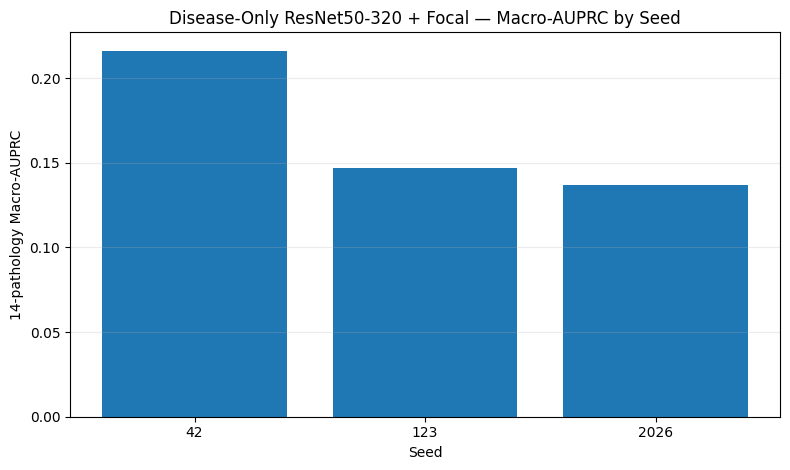

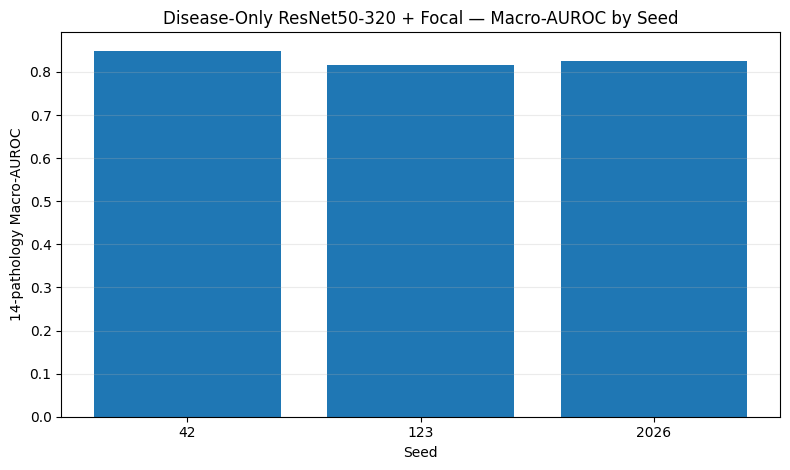

In [9]:
# ============================================================
# 9. Main stability figures
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(
    seed_df["seed"].astype(str),
    seed_df["macro_AUPRC_14"],
)
ax.set_xlabel("Seed")
ax.set_ylabel("14-pathology Macro-AUPRC")
ax.set_title(
    "Disease-Only ResNet50-320 + Focal — Macro-AUPRC by Seed"
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "macro_auprc_by_seed.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(
    seed_df["seed"].astype(str),
    seed_df["macro_AUROC_14"],
)
ax.set_xlabel("Seed")
ax.set_ylabel("14-pathology Macro-AUROC")
ax.set_title(
    "Disease-Only ResNet50-320 + Focal — Macro-AUROC by Seed"
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "macro_auroc_by_seed.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


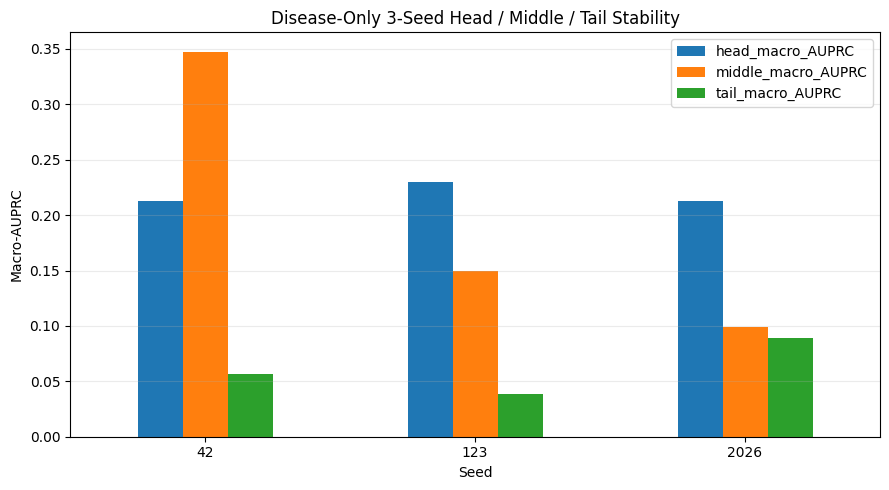

In [10]:
# ============================================================
# 10. Head / Middle / Tail seed stability figure
# ============================================================
hmt_plot = seed_df[
    [
        "seed",
        "head_macro_AUPRC",
        "middle_macro_AUPRC",
        "tail_macro_AUPRC",
    ]
].set_index("seed")

fig, ax = plt.subplots(figsize=(9, 5))
hmt_plot.plot(
    kind="bar",
    ax=ax,
)
ax.set_xlabel("Seed")
ax.set_ylabel("Macro-AUPRC")
ax.set_title(
    "Disease-Only 3-Seed Head / Middle / Tail Stability"
)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "hmt_auprc_by_seed.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


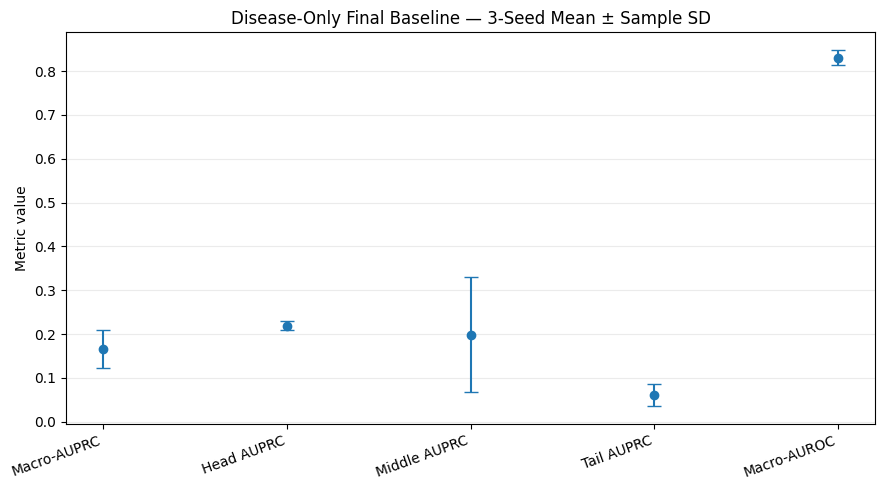

In [11]:
# ============================================================
# 11. Mean ± SD figure for key metrics
# ============================================================
key_metrics = [
    "macro_AUPRC_14",
    "head_macro_AUPRC",
    "middle_macro_AUPRC",
    "tail_macro_AUPRC",
    "macro_AUROC_14",
]

plot_rows = (
    three_seed_summary[
        three_seed_summary["metric"].isin(key_metrics)
    ]
    .set_index("metric")
    .loc[key_metrics]
)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_rows))

ax.errorbar(
    x,
    plot_rows["mean"].values,
    yerr=plot_rows["sample_sd"].values,
    fmt="o",
    capsize=5,
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Macro-AUPRC",
        "Head AUPRC",
        "Middle AUPRC",
        "Tail AUPRC",
        "Macro-AUROC",
    ],
    rotation=20,
    ha="right",
)

ax.set_ylabel("Metric value")
ax.set_title(
    "Disease-Only Final Baseline — 3-Seed Mean ± Sample SD"
)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "three_seed_mean_sd_key_metrics.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


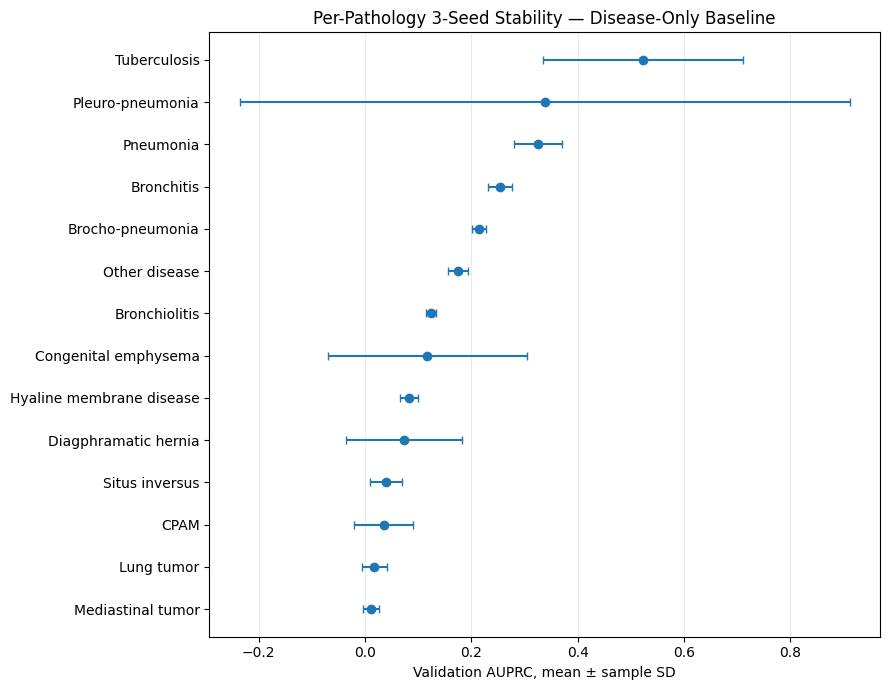

In [12]:
# ============================================================
# 12. Per-class AUPRC mean ± SD figure
# ============================================================
plot_pc = (
    merged[merged["label"] != "No finding"]
    .sort_values("AUPRC_mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))

y = np.arange(len(plot_pc))

ax.errorbar(
    plot_pc["AUPRC_mean"],
    y,
    xerr=plot_pc["AUPRC_sample_sd"],
    fmt="o",
    capsize=3,
)

ax.set_yticks(y)
ax.set_yticklabels(plot_pc["label"])
ax.set_xlabel("Validation AUPRC, mean ± sample SD")
ax.set_title(
    "Per-Pathology 3-Seed Stability — Disease-Only Baseline"
)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "per_class_auprc_mean_sd.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


In [13]:
# ============================================================
# 13. Create paper-ready summary
# ============================================================
stats_map = {
    row["metric"]: row
    for _, row in three_seed_summary.iterrows()
}

def fmt(metric):
    row = stats_map[metric]
    return (
        f"{row['mean']:.6f} ± "
        f"{row['sample_sd']:.6f}"
    )

summary_lines = [
    "Pedi-CGAM Lite — Stage 08C Disease-Only 3-Seed Summary",
    "=" * 72,
    "",
    "FROZEN CONFIGURATION",
    "- Backbone: ResNet50",
    "- Resolution: 320x320",
    "- Loss: Binary Focal Loss",
    "- gamma = 2.0",
    "- alpha weighting = none",
    "- Seeds: 42, 123, 2026",
    "- Permanent Stage 02 split",
    "- Calibration unused",
    "- Official test sealed",
    "",
    "3-SEED VALIDATION SUMMARY (mean ± sample SD)",
    f"- 14-pathology Macro-AUPRC: {fmt('macro_AUPRC_14')}",
    f"- Head Macro-AUPRC: {fmt('head_macro_AUPRC')}",
    f"- Middle Macro-AUPRC: {fmt('middle_macro_AUPRC')}",
    f"- Tail Macro-AUPRC: {fmt('tail_macro_AUPRC')}",
    f"- 14-pathology Macro-AUROC: {fmt('macro_AUROC_14')}",
    f"- Macro-F1 @ 0.5: {fmt('macro_F1_at_0.5')}",
    "",
    "INTERPRETATION",
    (
        "- Head-group AUPRC is relatively stable across seeds, "
        "while Middle/Tail metrics are substantially less stable."
    ),
    (
        "- Much of the instability is expected from ultra-rare "
        "validation classes containing only 1-3 positive cases."
    ),
    (
        "- Seed 42 was also used during loss selection; therefore "
        "this table is a replication/stability summary of the selected "
        "configuration rather than a fully independent performance estimate."
    ),
    (
        "- Future final-model variants should use the same three seeds "
        "for controlled mean ± SD comparisons."
    ),
    "",
    "NEXT SCIENTIFIC STEP",
    "- Keep ResNet50-320 + Focal Loss frozen.",
    "- Add disease + local-finding multitask supervision.",
    "- Do not touch calibration or official-test labels.",
]

summary_text = "\n".join(summary_lines)

print(summary_text)

(
    OUTPUT_DIR / "README_STAGE08C_RESULTS.txt"
).write_text(summary_text)


Pedi-CGAM Lite — Stage 08C Disease-Only 3-Seed Summary

FROZEN CONFIGURATION
- Backbone: ResNet50
- Resolution: 320x320
- Loss: Binary Focal Loss
- gamma = 2.0
- alpha weighting = none
- Seeds: 42, 123, 2026
- Permanent Stage 02 split
- Calibration unused
- Official test sealed

3-SEED VALIDATION SUMMARY (mean ± sample SD)
- 14-pathology Macro-AUPRC: 0.166541 ± 0.043269
- Head Macro-AUPRC: 0.218664 ± 0.010073
- Middle Macro-AUPRC: 0.198767 ± 0.131373
- Tail Macro-AUPRC: 0.061104 ± 0.025512
- 14-pathology Macro-AUROC: 0.830759 ± 0.017029
- Macro-F1 @ 0.5: 0.027373 ± 0.024042

INTERPRETATION
- Head-group AUPRC is relatively stable across seeds, while Middle/Tail metrics are substantially less stable.
- Much of the instability is expected from ultra-rare validation classes containing only 1-3 positive cases.
- Seed 42 was also used during loss selection; therefore this table is a replication/stability summary of the selected configuration rather than a fully independent performance estima

1344

In [14]:
# ============================================================
# 14. Final integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "Exactly 3 seed runs discovered",
        "passed": len(discovered) == 3,
    },
    {
        "check": "Seed set is exactly {42, 123, 2026}",
        "passed":
            set(seed_df["seed"].tolist())
            == {42, 123, 2026},
    },
    {
        "check": "All protocol/integrity checks passed",
        "passed":
            verification_df["all_checks_pass"].all(),
    },
    {
        "check": "Primary Macro-AUPRC finite for all seeds",
        "passed":
            np.isfinite(seed_df["macro_AUPRC_14"]).all(),
    },
    {
        "check": "3-seed sample SD computed",
        "passed":
            np.isfinite(
                three_seed_summary["sample_sd"]
            ).all(),
    },
    {
        "check": "Calibration remained unused",
        "passed": all(
            info["config"].get("calibration_used") is False
            for info in discovered.values()
        ),
    },
    {
        "check": "Official test remained sealed",
        "passed": all(
            info["config"].get("official_test_used") is False
            for info in discovered.values()
        ),
    },
])

checks["status"] = checks["passed"].map(
    {True: "PASS", False: "REVIEW"}
)

display(checks)

checks.to_csv(
    OUTPUT_DIR / "stage08c_final_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks["passed"].all()
    else "REVIEW"
)

print("\n" + "=" * 72)
print("STAGE 08C FINAL STATUS:", FINAL_STATUS)

if FINAL_STATUS == "PASS":
    print("✅ DISEASE-ONLY 3-SEED SUMMARY COMPLETE")
    print("🔒 ResNet50-320 + Focal Loss remains frozen")
    print("➡️ Next: disease + finding multitask supervision")
else:
    print("⚠️ REVIEW BEFORE MULTITASK TRAINING")

print("=" * 72)


,check,passed,status
0,Exactly 3 seed runs discovered,True,PASS
1,"Seed set is exactly {42, 123, 2026}",True,PASS
2,All protocol/integrity checks passed,True,PASS
3,Primary Macro-AUPRC finite for all seeds,True,PASS
4,3-seed sample SD computed,True,PASS
5,Calibration remained unused,True,PASS
6,Official test remained sealed,True,PASS



STAGE 08C FINAL STATUS: PASS
✅ DISEASE-ONLY 3-SEED SUMMARY COMPLETE
🔒 ResNet50-320 + Focal Loss remains frozen
➡️ Next: disease + finding multitask supervision


In [15]:
# ============================================================
# 15. ZIP entire Stage 08C folder into ONE downloadable file
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "PediCGAM_Stage08C_DiseaseOnly_3Seed_Summary_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError(
        "No Stage 08C outputs found to package."
    )

for p in source_files:
    if p.suffix.lower() in {".dcm", ".dicom"}:
        raise RuntimeError(
            f"STOP: DICOM detected in summary output: {p}"
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        rel = p.relative_to(OUTPUT_DIR)

        zf.write(
            p,
            arcname=str(
                Path("stage08c_diseaseonly_3seed_summary")
                / rel
            ),
        )

with zipfile.ZipFile(ZIP_FILE, "r") as zf:
    bad = zf.testzip()
    names = set(zf.namelist())

if bad is not None:
    raise RuntimeError(
        f"ZIP integrity failure at: {bad}"
    )

expected = {
    str(
        Path("stage08c_diseaseonly_3seed_summary")
        / p.relative_to(OUTPUT_DIR)
    )
    for p in source_files
}

missing = expected - names

if missing:
    raise RuntimeError(
        "ZIP missing outputs: "
        + ", ".join(sorted(missing)[:20])
    )

print("✅ STAGE 08C COMPLETE ZIP CREATED")
print("File:", ZIP_FILE)
print("Archived files:", len(source_files))
print(
    f"ZIP size: "
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB"
)
print("ZIP integrity: PASS")
print("DICOM files included: NO")


✅ STAGE 08C COMPLETE ZIP CREATED
File: /kaggle/working/PediCGAM_Stage08C_DiseaseOnly_3Seed_Summary_All_Outputs.zip
Archived files: 12
ZIP size: 0.31 MB
ZIP integrity: PASS
DICOM files included: NO


## After Stage 08C passes

The disease-only reference is now documented across three seeds.

Next, move to **richer radiological supervision** while preserving:

- the same frozen Stage 02 split,
- ResNet50 @ 320×320,
- Focal Loss,
- the same augmentation policy,
- the same primary validation metric,
- and the same seed set for later paper-quality comparisons.

Next experiment family:

- `09A_Disease_and_Finding_Multitask_Seed42.ipynb`
- then replicate important final variants on seeds 123 and 2026 after the architecture is stabilized.

The official test remains sealed.
